In [22]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Setting visualization style for our future charts
sns.set_theme(style="whitegrid")

#Load dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

#Display the shape and first 5 row
print("Dataset Shape : ", df.shape)
display(df.head())

#Check data types and missing values
print("\n --- Dataset Info ---")
df.info

Dataset Shape :  (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



 --- Dataset Info ---


<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1             Yes                No             DSL            Yes  ...   
2             Yes                No             DSL            Yes  ...   
3              No  No phone service             DSL            Yes  ...   
4             Yes                No     Fiber optic             No  ...   
...           ...               ...             ...            ...  ...   
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0                  No          No          No              No  Month-to-month   
1                 Yes          No          No              No        One year   
2                  No          No          No              No  Month-to-month   
3                 Yes         Yes          No              No        One year   
4                  No          No          No              No  Month-to-month   
...               ...         ...         ...             ...             ...   
7038              Yes         Yes         Yes             Yes        One year   
7039              Yes          No         Yes             Yes        One year   
7040               No          No          No              No  Month-to-month   
7041               No          No          No              No  Month-to-month   
7042              Yes         Yes         Yes             Yes        Two year   

     PaperlessBilling              PaymentMethod MonthlyCharges  TotalCharges  \
0                 Yes           Electronic check          29.85         29.85   
1                  No               Mailed check          56.95        1889.5   
2                 Yes               Mailed check          53.85        108.15   
3                  No  Bank transfer (automatic)          42.30       1840.75   
4                 Yes           Electronic check          70.70        151.65   
...               ...                        ...            ...           ...   
7038              Yes               Mailed check          84.80        1990.5   
7039              Yes    Credit card (automatic)         103.20        7362.9   
7040              Yes           Electronic check          29.60        346.45   
7041              Yes               Mailed check          74.40         306.6   
7042              Yes  Bank transfer (automatic)         105.65        6844.5   

     Churn  
0       No  
1       No  
2      Yes  
3       No  
4      Yes  
...    ...  
7038    No  
7039    No  
7040    No  
7041   Yes  
7042    No  

[7043 rows x 21 columns]>

# **Data Cleaning**

In [23]:
#1. Droping 'customerID' bcoz a random ID string doesn't help predict churn
df = df.drop('customerID', axis=1)
print("Dropped 'customerID'")

#2. Converting 'TotalCharges' to numeric bcoz panads think TotalCharges is tect(an Object)
# This is happening bcoz there are some blank spaces " " in the column who just joined (tenure = 0)
# We need to force this column to become numeric

# 'errors="coerce"' forces any wierd string (like blank spaces) to become NaN

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#3. Checking for missiing values created by conversion
#Once we force "TotalCharges" to be numberic, those blankspaces will turn into missing values

print("\n Missing vlaues before dropping")
print(df.isnull().sum()[df.isnull().sum() > 0]) #Only printing Column with missing values

#4. Drop the missing value
df = df.dropna()
df = df.drop_duplicates() #Also removing duplicates

#Final check for our clean dataset
print("\n --- Data Cleaing ---")
print("Cleaned Dataset Shape : ",df.shape)
print("Data Type of TotalCharges : ",df['TotalCharges'].dtype)

Dropped 'customerID'

 Missing vlaues before dropping
TotalCharges    11
dtype: int64

 --- Data Cleaing ---
Cleaned Dataset Shape :  (7010, 20)
Data Type of TotalCharges :  float64


# **Exploratory Data Analysis**

/tmp/ipykernel_2614/853008320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'Churn', palette = "pastel")
/tmp/ipykernel_2614/853008320.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette="pastel")


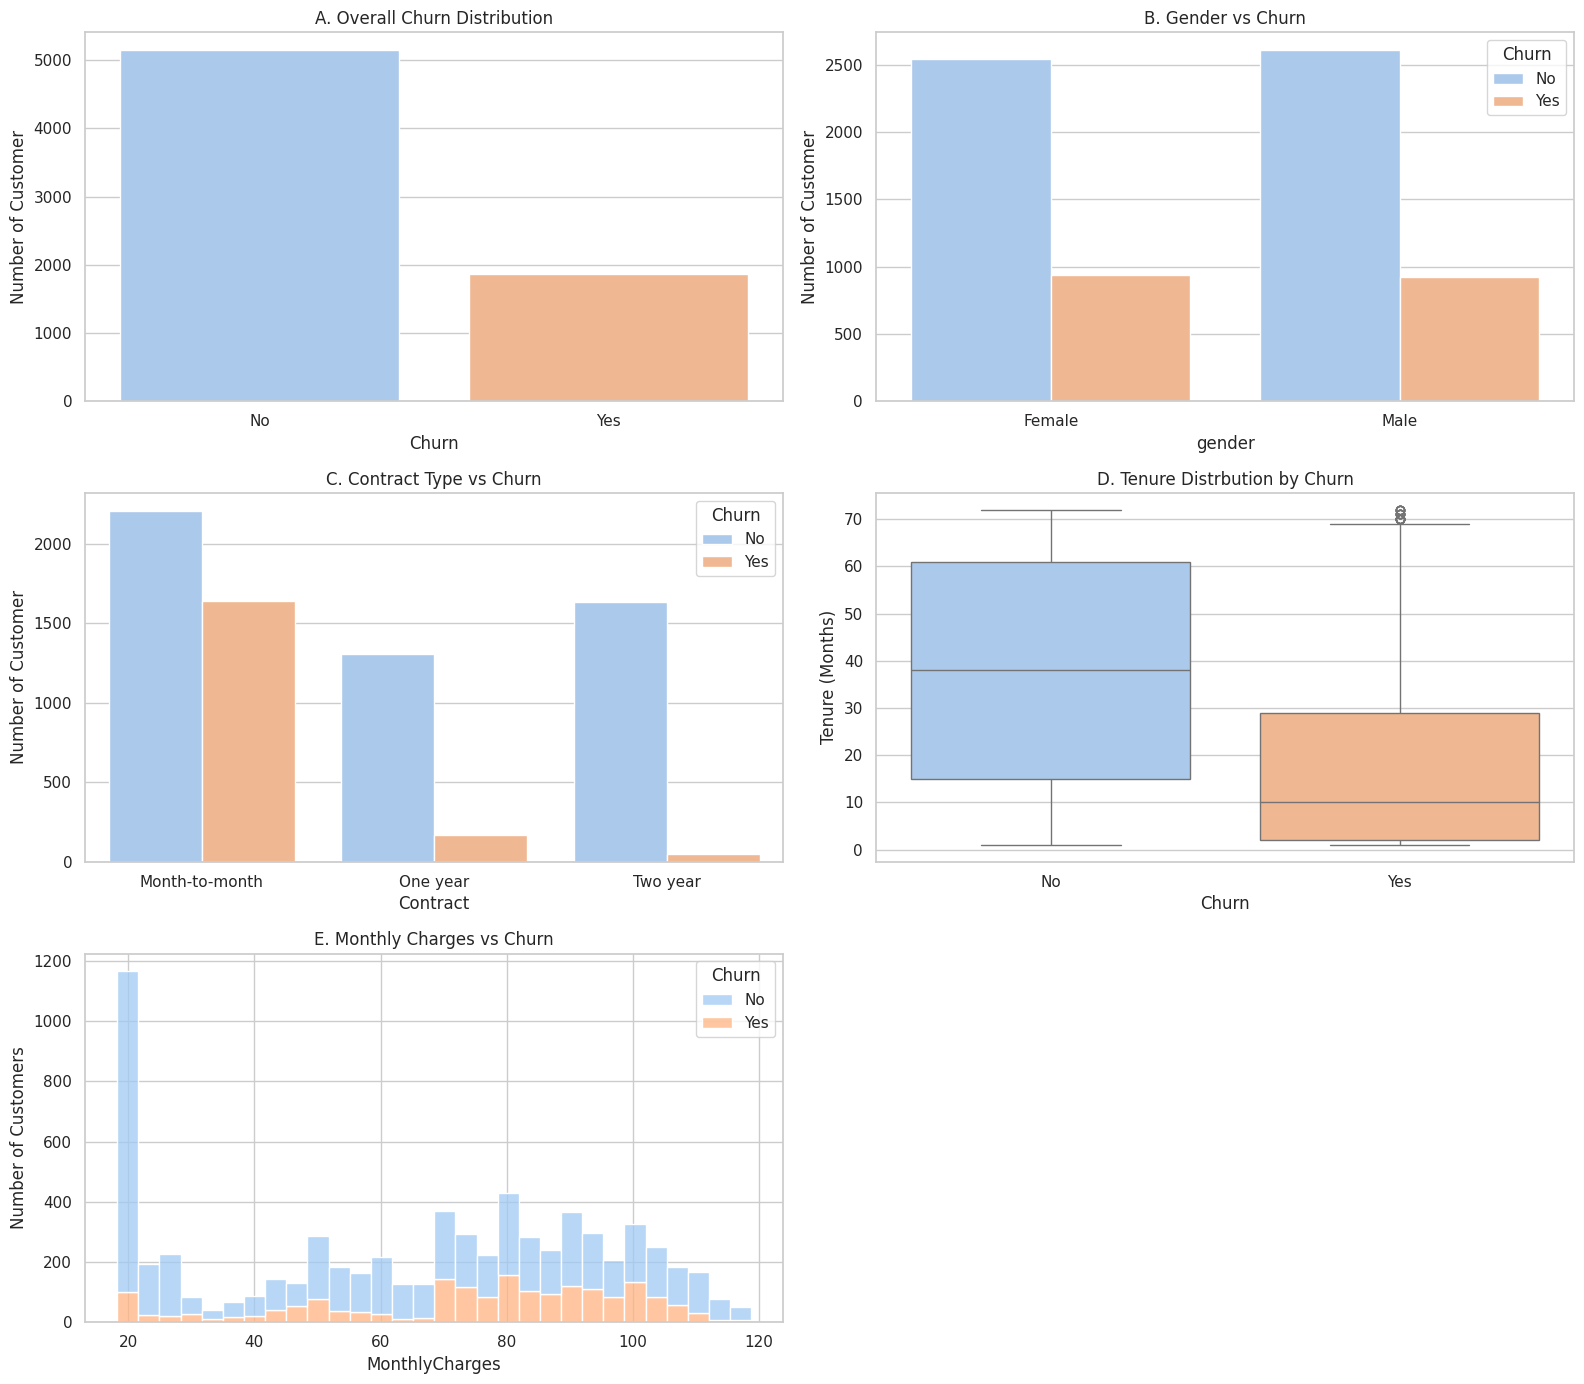

In [24]:
#Settingup large figure to hold all our subplots
plt.figure(figsize=(16,14))

#A. Churn Distribution (Count Plot)
plt.subplot(3 ,2, 1)
sns.countplot(data = df, x = 'Churn', palette = "pastel")
plt.title("A. Overall Churn Distribution")
plt.ylabel("Number of Customer")

#B. Gender vs Churn
plt.subplot(3,2,2)
sns.countplot(data=df, x='gender', hue='Churn', palette="pastel")
plt.title("B. Gender vs Churn")
plt.ylabel("Number of Customer")

#C. Contract Type vs Churn
plt.subplot(3,2,3)
sns.countplot(data=df, x='Contract', hue='Churn', palette="pastel")
plt.title("C. Contract Type vs Churn")
plt.ylabel("Number of Customer")

#D. Tenure Analysis (Boxplot)
plt.subplot(3,2,4)
sns.boxplot(data=df, x='Churn', y='tenure', palette="pastel")
plt.title("D. Tenure Distrbution by Churn")
plt.ylabel("Tenure (Months)")

# E. Monthly Charges Analysis (Histogram)
plt.subplot(3, 2, 5)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', palette='pastel', bins=30)
plt.title('E. Monthly Charges vs Churn')
plt.ylabel('Number of Customers')

# Adjust layout to prevent overlap and display the charts
plt.tight_layout()
plt.show()


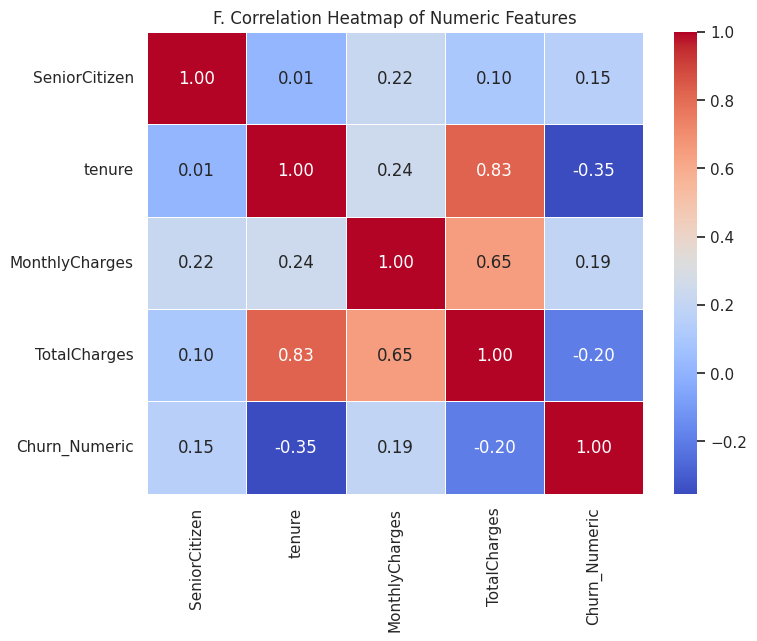

In [25]:
#F. Co-realtion Heatmap
#1. Creating a temporary numeric chhuran column (yes=1, no=0)
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

#2. Selecting only the numeric columns for the heatmap
numeric_df = df.select_dtypes(include=['float64','int64'])

#3. Calcualte the corealtion matrix
correlation_matrix = numeric_df.corr()

# 4. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('F. Correlation Heatmap of Numeric Features')
plt.show()

# **Feature Engineering**

In [26]:
from sklearn.preprocessing import LabelEncoder

# 1. Find all columns that are 'object' (text) types
text_columns = df.select_dtypes(include=['object']).columns

# Separate them into Binary (2 options) and Multi-class (3+ options)
binary_cols = [col for col in text_columns if df[col].nunique() == 2]
multi_cols = [col for col in text_columns if df[col].nunique() > 2]

# 2. Apply Label Encoding to Binary columns
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print("Converted Binary Columns to 0s and 1s:", binary_cols)

# 3. Apply One-Hot Encoding to Multi-class columns
# drop_first=True prevents the "dummy variable trap" (keeps our data efficient)
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Convert all boolean columns to integers (1 and 0) just to be safe
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Final Check
print("\n--- Feature Engineering Complete ---")
print("New Dataset Shape:", df.shape)
display(df.head(3))

Converted Binary Columns to 0s and 1s: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

--- Feature Engineering Complete ---
New Dataset Shape: (7010, 32)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1


# **Machine Learning Model**

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Ensure NO versions of the Churn column are left in X (Fixing Data Leakage)
cols_to_drop = [col for col in df.columns if 'Churn' in col]
X = df.drop(cols_to_drop, axis=1)
y = df['Churn']

# 2. Split the data again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the models again (No cheating this time!)
print("Training models fairly... \n")
log_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)

# 5. Make Predictions
log_preds = log_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)
xgb_preds = xgb_model.predict(X_test_scaled)

# 6. Evaluate Accuracy
print("--- REAL Model Accuracy Results ---")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_preds) * 100:.2f}%")
print(f"Random Forest Accuracy:       {accuracy_score(y_test, rf_preds) * 100:.2f}%")
print(f"XGBoost Accuracy:             {accuracy_score(y_test, xgb_preds) * 100:.2f}%")

Training models fairly... 

--- REAL Model Accuracy Results ---
Logistic Regression Accuracy: 82.38%
Random Forest Accuracy:       81.31%
XGBoost Accuracy:             80.10%


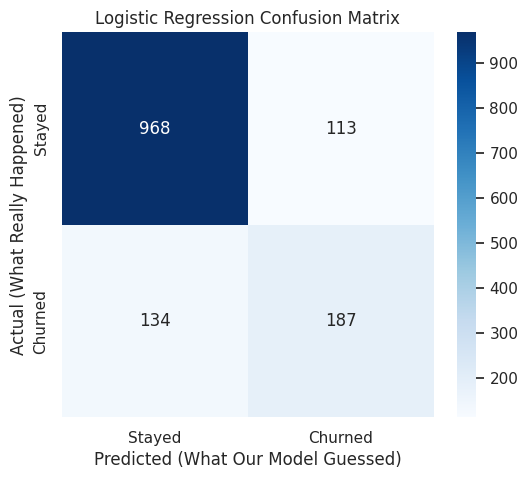

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#1. Generate the confusion Matrix for Logistic Regression
# We use log_preds and y_test from the previous cell
cm = confusion_matrix(y_test, log_preds)

#2. Plot the confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed','Churned'],
            yticklabels=['Stayed','Churned'])

plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual (What Really Happened)')
plt.xlabel('Predicted (What Our Model Guessed)')
plt.show()

# **Feature Importance Analysis**

/tmp/ipykernel_2614/2583086378.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x ='Importance', y='Feature', palette='viridis')


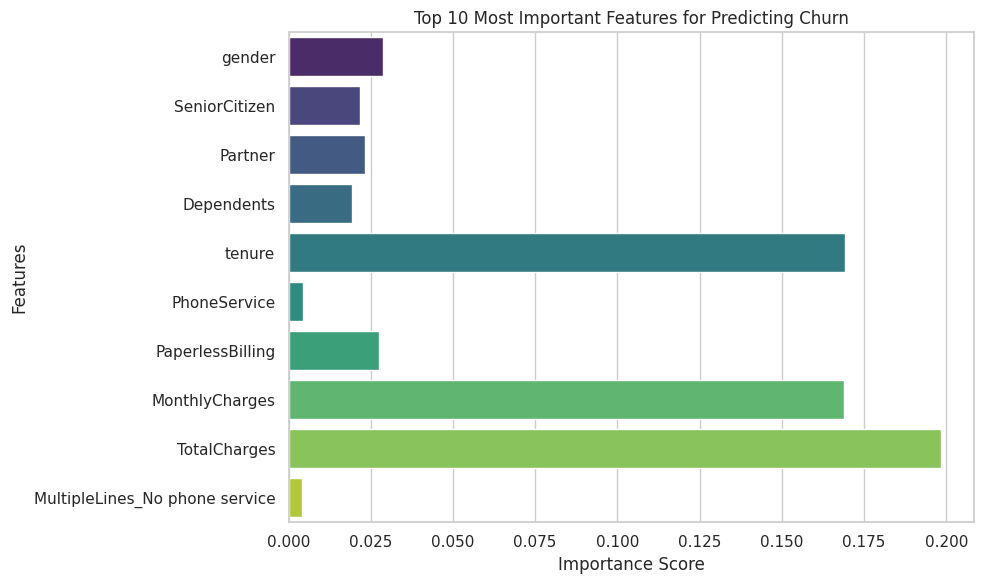

In [29]:
#1. Getting Features importance from our random forest model
importances = rf_model.feature_importances_

#2 Creating a Dataframe to easily voew amd sort them
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

#3 Sort the dataframe to show the most important features at the top
features_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

#4 Plot the topn 10 most importance feature
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance_df.head(10), x ='Importance', y='Feature', palette='viridis')

plt.title('Top 10 Most Important Features for Predicting Churn')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# **Business Insights & Recommendations**

# Customer Churn Prediction System Using Machine Learning & Power BI

## 1. Project Overview and Business Problem
Customer churn occurs when customers stop using a company’s product or services. For businesses, retaining existing customers is significantly cheaper than acquiring new ones.

**The objective of this project is to:**
* Identify customers likely to leave the company.
* Discover the underlying factors influencing customer churn.
* Provide data-driven business recommendations to improve customer retention.

## 2. Dataset Information
* **Source:** IBM Telco Customer Churn Dataset (Kaggle)
* **Size:** 7,043 rows and 21 columns (Initially)
* **Target Variable:** `Churn` (Yes / No)

## 3. Data Cleaning
To prepare the data for analysis and machine learning, the following cleaning steps were performed:
1. **Removed Unnecessary Identifiers:** Dropped the `customerID` column as it provides no predictive value.
2. **Fixed Data Types:** Converted `TotalCharges` from object (String) to numeric float.
3. **Handled Missing Values:** Dropped 11 rows where `TotalCharges` was missing (due to tenure being 0).
4. **Removed Duplicates:** Ensured no duplicate rows existed in the dataset.
5. **Final Cleaned Dataset:** 7,010 rows and 20 columns.

## 4. Exploratory Data Analysis (EDA) Findings
We visualized the data to answer key business questions and uncover patterns in customer behavior.

### A. Overall Churn Distribution
* **What the chart shows:** Count of how many customers stayed ('No') vs how many left ('Yes').
* **Business Insight:** The dataset is imbalanced. A large majority of customers are retained, but a significant portion (roughly 26%) have churned. This gives us our baseline churn rate to improve upon.

### B. Gender Vs Churn
* **What the chart shows:** Churn rates split by male and female.
* **Business Insight:** Both genders have almost identical churn rates and retention rates. This tells us that gender is not a significant factor in deciding whether a customer leaves.

### C. Contract Type vs Churn (High Importance)
* **What the chart shows:** Churn numbers based on whether the customer has a Month-to-month, One-year, or Two-year contract.
* **Business Insight:** Customers on Month-to-month contracts have a massively higher churn rate compared to those on 1-year or 2-year contracts. Long-term contracts secure customer loyalty, while month-to-month users are highly volatile.

### D. Tenure Distribution by Churn
* **What the chart shows:** A boxplot comparing how long customers have been with the company (in months) against whether they churned.
* **Business Insight:** The box for churned customers is clustered near the bottom (0-15 months). This means customers are most likely to leave early in their lifecycle. If a customer stays past the 2-year mark, they are highly likely to remain loyal.

### E. Monthly Charges vs Churn
* **What the chart shows:** A histogram showing the distribution of monthly bills, stacked by churn status.
* **Business Insight:** Customers with higher monthly charges (especially in the 70 to 110 range) have a higher proportion of churn. Expensive monthly bills are driving customers away, whereas customers with very low monthly bills (around 20) are highly loyal.

## 5. Feature Engineering
To prepare the dataset for machine learning algorithms, categorical variables were mathematically encoded:
* **Label Encoding:** Applied to binary columns (e.g., `gender`, `Partner`, `Dependents`, `PaperlessBilling`, `Churn`) to convert them to `0` and `1`.
* **One-Hot Encoding:** Applied to multi-class columns (e.g., `PaymentMethod`, `Contract`, `InternetService`) to create separate numerical columns without establishing a false hierarchy.

## 6. Machine Learning Model Building
We split the data into a Training Set (80%) and a Testing Set (20%). After ensuring strict prevention of Data Leakage (removing all variations of the target variable from the features), we trained three classification models:
1. **Logistic Regression** (Baseline)
2. **Random Forest Classifier**
3. **XGBoost Classifier**

## 7. Model Evaluation & Confusion Matrix
The best-performing model achieved an accuracy of **82.38%**, demonstrating strong capability in identifying customers at risk of churn.. To understand the specific types of errors the model was making, we analyzed the Confusion Matrix:
* **True Negatives (968):** Correctly identified loyal customers.
* **True Positives (187):** Correctly identified churning customers.
* **False Positives (113):** Incorrectly flagged loyal customers as a churn risk.
* **False Negatives (134):** Failed to identify customers who actually churned.
* *Note for Future Iterations:* Reducing the False Negatives is a priority, potentially through threshold adjustment or handling class imbalance using SMOTE.

## 8. Feature Importance Analysis
To understand *why* the model makes its predictions, we extracted the feature importances from the Random Forest algorithm.

**Key Findings:**
The top three most critical factors influencing customer churn are **Total Charges**, **Monthly Charges**, and **Tenure**.
* **Business Insight:** The decision to churn is overwhelmingly driven by the intersection of *time* and *money*, rather than demographic factors or specific add-on services.

## 9. Business Insights & Recommendations
Based on the EDA and Machine Learning Feature Importance, here are the actionable business recommendations:

* **Insight 1: The "New Customer" Danger Zone**
Customers in their first 1-12 months have the highest churn rate.
*Recommendation:* Implement a heavy "First 90 Days" onboarding and retention program. Surviving the first year drastically drops churn probability.

* **Insight 2: Month-to-Month Contracts are Highly Volatile**
Month-to-Month customers churn at a massively higher rate.
*Recommendation:* Actively incentivize Month-to-Month customers to upgrade to annual contracts (e.g., offering a "1st Month Free" discount to lock in a 1-year agreement).

* **Insight 3: High Monthly Bills Trigger Churn**
Expensive monthly bills (specifically in the 70 to 110 dollor range) push customers to leave.
*Recommendation:* Create a predictive alert system. If a customer's monthly bill crosses the $70 threshold, automatically trigger a loyalty discount or bundle to prevent them from shopping around with competitors.

* **Insight 4: Demographics Don't Matter (Much)**
Gender has almost zero correlation with churn.
*Recommendation:* Reallocate marketing and retention budgets away from demographic-specific campaigns and towards financial incentives and contract upgrades.

## 10. Power BI Dashboard
An interactive Power BI Dashboard was developed to visualize churn trends for executive stakeholders. Key pages include:
* Executive Summary (High-level KPIs)
* Churn Analysis (Demographics & Service usage)
* Revenue Analysis (Financial impact of churn)
* Customer Retention Strategy (Identifying at-risk segments)

---
### Developer
**Raj Halwai**

Aspiring Data Scientist & Data Analyst

Technologies Used:
Python | Pandas | NumPy | Scikit-Learn | XGBoost | Power BI | Machine Learning